# Caser: Personalized Top-N Sequential Recommendation via Convolutional Sequence Embedding

## Paper

Caser: Personalized Top-N Sequential Recommendation via Convolutional Sequence Embedding

Published in WSDM 2018

---

## Objective

Implement Caser from scratch using MovieLens-100K.

Unlike GRU4Rec, Caser treats the user's interaction history as an
**embedding matrix** and applies **2D convolutional filters** to learn
both local sequential patterns and latent feature interactions.

---

## Pipeline

MovieLens

↓

Sort by Timestamp

↓

User Sequences

↓

Sliding Window

↓

Padding

↓

Embedding Matrix

↓

Horizontal CNN

+

Vertical CNN

↓

Fully Connected Layer

↓

Item Scores

↓

Recommendation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

In [2]:
ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
print("Shape :", ratings.shape)
print()

print(ratings.info())
print()

print("Users :", ratings.user_id.nunique())
print("Movies :", ratings.movie_id.nunique())

Shape : (100000, 4)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Users : 943
Movies : 1682


In [4]:
ratings = ratings.sort_values(

    by=[
        "user_id",
        "timestamp"
    ]

).reset_index(drop=True)

In [5]:
user_mapping = {

    u:i

    for i, u in enumerate(
        ratings.user_id.unique()
    )
}

movie_mapping = {

    m:i+1

    for i, m in enumerate(
        ratings.movie_id.unique()
    )
}

ratings["user_id"] = ratings.user_id.map(
    user_mapping
)

ratings["movie_id"] = ratings.movie_id.map(
    movie_mapping
)

PAD_TOKEN = 0

NUM_USERS = ratings.user_id.nunique()
NUM_MOVIES = ratings.movie_id.nunique()

print(NUM_USERS)
print(NUM_MOVIES)

943
1682


In [6]:
user_sequences = (

    ratings

    .groupby("user_id")["movie_id"]

    .apply(list)
)

user_sequences.head()

user_id
0    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
1    [273, 251, 274, 275, 276, 277, 278, 279, 280, ...
2    [309, 307, 317, 318, 126, 319, 280, 320, 321, ...
3    [251, 276, 309, 345, 255, 280, 349, 347, 356, ...
4    [127, 250, 363, 40, 364, 365, 17, 9, 38, 204, ...
Name: movie_id, dtype: object

In [7]:
sequence_lengths = user_sequences.apply(len)

sequence_lengths.describe()

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: movie_id, dtype: float64

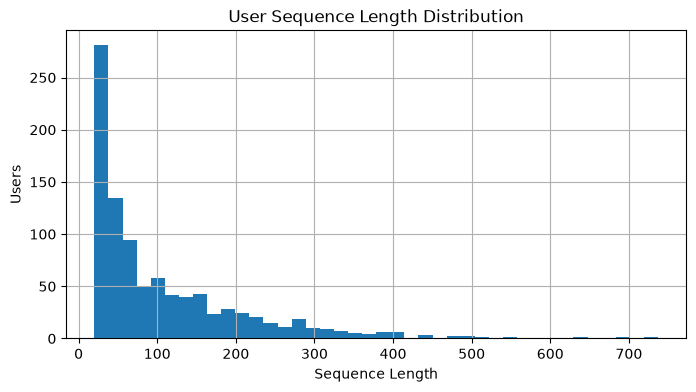

In [8]:
plt.figure(figsize=(8,4))

plt.hist(
    sequence_lengths,
    bins=40
)

plt.xlabel("Sequence Length")
plt.ylabel("Users")
plt.title("User Sequence Length Distribution")

plt.grid(True)

plt.show()

In [9]:
train_sequences = []
targets = []

for sequence in user_sequences:

    if len(sequence) < 2:
        continue

    for i in range(1, len(sequence)):

        train_sequences.append(
            sequence[:i]
        )

        targets.append(
            sequence[i]
        )

In [10]:
for i in range(5):

    print("Input :", train_sequences[i])

    print("Target:", targets[i])

    print("-"*40)

Input : [1]
Target: 2
----------------------------------------
Input : [1, 2]
Target: 3
----------------------------------------
Input : [1, 2, 3]
Target: 4
----------------------------------------
Input : [1, 2, 3, 4]
Target: 5
----------------------------------------
Input : [1, 2, 3, 4, 5]
Target: 6
----------------------------------------


In [11]:
max_length = max(

    len(sequence)

    for sequence in train_sequences
)

print(max_length)

736


In [12]:
MAX_LEN = 50

train_sequences = [

    sequence[-MAX_LEN:]

    for sequence in train_sequences
]

In [13]:
PAD_TOKEN = 0

padded_sequences = []

for sequence in train_sequences:

    padding = [

        PAD_TOKEN

    ] * (MAX_LEN - len(sequence))

    padded_sequences.append(

        padding + sequence
    )

In [14]:
padded_sequences = np.array(
    padded_sequences,
    dtype=np.int64
)

targets = np.array(
    targets,
    dtype=np.int64
)

print(padded_sequences.shape)
print(targets.shape)

(99057, 50)
(99057,)


In [15]:
train_sequences, test_sequences, train_targets, test_targets = train_test_split(

    padded_sequences,

    targets,

    test_size=0.2,

    random_state=42,

    shuffle=True
)

In [16]:
class CaserDataset(Dataset):

    def __init__(

        self,

        sequences,

        targets

    ):

        self.sequences = torch.LongTensor(sequences)

        self.targets = torch.LongTensor(targets)

    def __len__(self):

        return len(self.sequences)

    def __getitem__(self, idx):

        return (

            self.sequences[idx],

            self.targets[idx]
        )

In [17]:
train_dataset = CaserDataset(

    train_sequences,

    train_targets
)

test_dataset = CaserDataset(

    test_sequences,

    test_targets
)

In [18]:
BATCH_SIZE = 256

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False
)

In [19]:
batch_sequences, batch_targets = next(

    iter(train_loader)
)

print(batch_sequences.shape)
print(batch_targets.shape)

torch.Size([256, 50])
torch.Size([256])


In [25]:
class Caser(nn.Module):

    def __init__(

        self,

        num_items,

        max_len,

        embedding_dim=64,

        num_filters=16

    ):

        super().__init__()

        self.embedding = nn.Embedding(

            num_embeddings=num_items + 1,

            embedding_dim=embedding_dim,

            padding_idx=PAD_TOKEN

        )

        self.max_len = max_len

        self.embedding_dim = embedding_dim

        self.num_filters = num_filters


        # Vertical Convolution
        self.vertical_conv = nn.Conv2d(

            in_channels=1,

            out_channels=num_filters,

            kernel_size=(max_len, 1)

        )


        # Horizontal Convolutions
        self.horizontal_convs = nn.ModuleList(

            [

                nn.Conv2d(

                    in_channels=1,

                    out_channels=num_filters,

                    kernel_size=(h, embedding_dim)

                )

                for h in range(

                    1,

                    max_len + 1

                )

            ]

        )


        # Fully Connected Layer
        self.fc = nn.Linear(

            num_filters * embedding_dim +

            num_filters * max_len,

            embedding_dim

        )


    def forward(

        self,

        sequences

    ):

        # ------------------------------------
        # Embedding
        # (batch, max_len)
        # ->
        # (batch, max_len, embedding_dim)
        # ------------------------------------

        x = self.embedding(

            sequences

        )


        # ------------------------------------
        # Add channel dimension
        # (batch,1,max_len,embedding_dim)
        # ------------------------------------

        x = x.unsqueeze(1)


        # ------------------------------------
        # Vertical CNN
        # ------------------------------------

        vertical = self.vertical_conv(

            x

        )

        vertical = vertical.view(

            vertical.size(0),

            -1

        )


        # ------------------------------------
        # Horizontal CNN
        # ------------------------------------

        horizontal_outputs = []

        for conv in self.horizontal_convs:

            feature = conv(

                x

            )

            feature = F.relu(

                feature

            )

            feature = feature.squeeze(3)

            feature = F.max_pool1d(

                feature,

                feature.size(2)

            )

            feature = feature.squeeze(2)

            horizontal_outputs.append(

                feature

            )


        horizontal = torch.cat(

            horizontal_outputs,

            dim=1

        )


        # ------------------------------------
        # Merge Features
        # ------------------------------------

        representation = torch.cat(

            [

                vertical,

                horizontal

            ],

            dim=1

        )


        # ------------------------------------
        # Fully Connected
        # ------------------------------------

        representation = self.fc(

            representation

        )

        representation = F.relu(

            representation

        )

        # representation = F.normalize(

        #     representation,

        #     dim=1

        # )


        return representation

In [29]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

model = Caser(

    num_items=NUM_MOVIES,

    max_len=MAX_LEN,

    embedding_dim=64,

    num_filters=16

).to(device)
model

Caser(
  (embedding): Embedding(1683, 64, padding_idx=0)
  (vertical_conv): Conv2d(1, 16, kernel_size=(50, 1), stride=(1, 1))
  (horizontal_convs): ModuleList(
    (0): Conv2d(1, 16, kernel_size=(1, 64), stride=(1, 1))
    (1): Conv2d(1, 16, kernel_size=(2, 64), stride=(1, 1))
    (2): Conv2d(1, 16, kernel_size=(3, 64), stride=(1, 1))
    (3): Conv2d(1, 16, kernel_size=(4, 64), stride=(1, 1))
    (4): Conv2d(1, 16, kernel_size=(5, 64), stride=(1, 1))
    (5): Conv2d(1, 16, kernel_size=(6, 64), stride=(1, 1))
    (6): Conv2d(1, 16, kernel_size=(7, 64), stride=(1, 1))
    (7): Conv2d(1, 16, kernel_size=(8, 64), stride=(1, 1))
    (8): Conv2d(1, 16, kernel_size=(9, 64), stride=(1, 1))
    (9): Conv2d(1, 16, kernel_size=(10, 64), stride=(1, 1))
    (10): Conv2d(1, 16, kernel_size=(11, 64), stride=(1, 1))
    (11): Conv2d(1, 16, kernel_size=(12, 64), stride=(1, 1))
    (12): Conv2d(1, 16, kernel_size=(13, 64), stride=(1, 1))
    (13): Conv2d(1, 16, kernel_size=(14, 64), stride=(1, 1))
    (

In [30]:
batch_sequences, batch_targets = next(

    iter(train_loader)

)

batch_sequences = batch_sequences.to(device)

representation = model(

    batch_sequences

)

print(representation.shape)

torch.Size([256, 64])


In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3,

    weight_decay=1e-5

)

In [32]:
NUM_EPOCHS = 20

train_losses = []
train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for sequence, positive in train_loader:

        sequence = sequence.to(device)

        positive = positive.to(device)

        optimizer.zero_grad()


        # sequence representation
        representation = model(sequence)


        # item embeddings
        item_embedding = model.embedding(

            positive

        )


        # similarity matrix
        scores = torch.matmul(

            representation,

            item_embedding.T

        )


        labels = torch.arange(

            scores.size(0),

            device=device

        )


        loss = criterion(

            scores,

            labels

        )

        loss.backward()

        optimizer.step()


        running_loss += loss.item()

        prediction = scores.argmax(dim=1)

        correct += (

            prediction == labels

        ).sum().item()

        total += positive.size(0)


    epoch_loss = running_loss / len(train_loader)

    epoch_acc = correct / total


    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_acc)


    print(

        f"Epoch {epoch+1:2d}"

        f" | Loss {epoch_loss:.4f}"

        f" | Accuracy {epoch_acc:.4f}"

    )

Epoch  1 | Loss 5.5587 | Accuracy 0.0039
Epoch  2 | Loss 5.5434 | Accuracy 0.0039


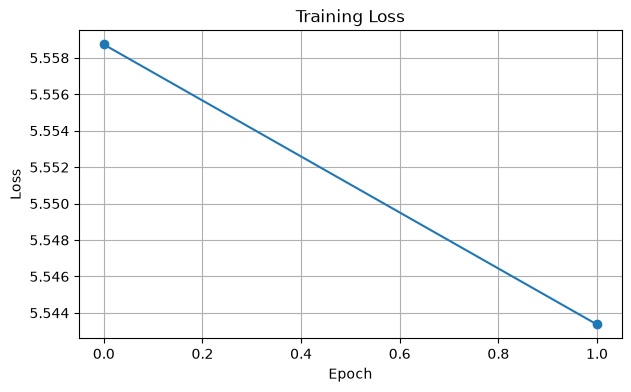

In [33]:
plt.figure(figsize=(7,4))

plt.plot(

    train_losses,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

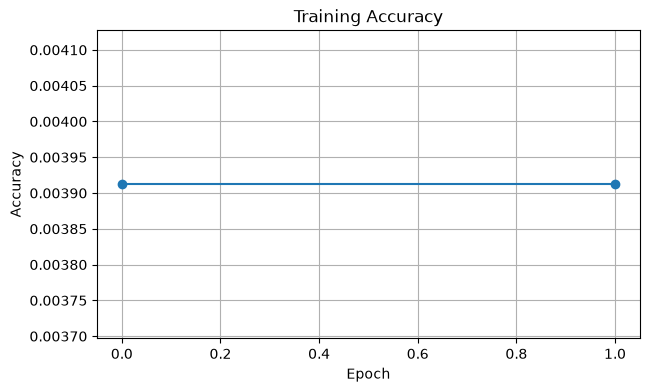

In [34]:
plt.figure(figsize=(7,4))

plt.plot(

    train_accuracies,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.show()

In [35]:
def hit_rate_at_k(

    topk,

    targets

):

    hits = 0

    for prediction, target in zip(

        topk,

        targets

    ):

        if target.item() in prediction:

            hits += 1

    return hits / len(targets)



import math

def ndcg_at_k(

    topk,

    targets

):

    ndcg = 0

    for prediction, target in zip(

        topk,

        targets

    ):

        prediction = prediction.tolist()

        target = target.item()

        if target in prediction:

            rank = prediction.index(target)

            ndcg += 1 / math.log2(

                rank + 2

            )

    return ndcg / len(targets)

In [36]:
model.eval()

all_movie_embeddings = model.embedding.weight

K = 10

all_topk = []

all_targets = []

with torch.no_grad():

    for sequence, positive in test_loader:

        sequence = sequence.to(device)

        positive = positive.to(device)


        representation = model(sequence)


        scores = torch.matmul(

            representation,

            all_movie_embeddings.T

        )


        # remove padding
        scores[:, PAD_TOKEN] = -1e9


        # mask watched movies
        for i in range(sequence.size(0)):

            history = sequence[i]

            history = history[history != PAD_TOKEN]

            scores[i, history] = -1e9


        topk = torch.topk(

            scores,

            K,

            dim=1

        ).indices


        all_topk.extend(

            topk.cpu()

        )

        all_targets.extend(

            positive.cpu()

        )

In [37]:
hr10 = hit_rate_at_k(

    all_topk,

    all_targets

)

ndcg10 = ndcg_at_k(

    all_topk,

    all_targets

)

print(f"HitRate@10 : {hr10:.4f}")

print(f"NDCG@10    : {ndcg10:.4f}")

HitRate@10 : 0.0264
NDCG@10    : 0.0113


In [ ]:
# orignal caser paper implemented with bpr loss not with cross entropy loss. So, the results are not same as original paper.